# High-Quality Slide Illustrations

Runs a 128³ LPT simulation with nside=128 and exports three publication-quality
PNG illustrations to `illustrations/`:

1. **Initial Gaussian density field** — 3D orthogonal-face view
2. **Final LPT density field** — 3D orthogonal-face view, log-scaled
3. **Spherical projection** — HEALPix Mollweide map, log-scaled

In [16]:
import os

os.environ["JAX_PLATFORM_NAME"] = "cpu"  # or "cpu" if you want to run on CPU
os.environ["JAX_PLATFORMS"] = "cpu"  # or "cpu" if you want to run on CPU
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import jax_fli as jfli
import matplotlib.pyplot as plt

os.makedirs("illustrations", exist_ok=True)

key = jax.random.PRNGKey(0)
mesh_size = (256, 256, 256)
box_size = (1000.0, 1000.0, 1000.0)
nside = 256
shell_width = 100.0
cosmo = jc.Planck18()

print(f"Devices: {jax.devices()}")

# Set font size for plots and activate tex rendering
plt.rcParams.update({"font.size": 22, "text.usetex": True})

Devices: [CpuDevice(id=0)]


In [17]:
nz_shear = jfli.io.get_stage3_nz_shear()
ells = jnp.arange(1, 2000)
cl_shear = jfli.compute_theory_cl(jc.Planck18(), ells, nz_shear)

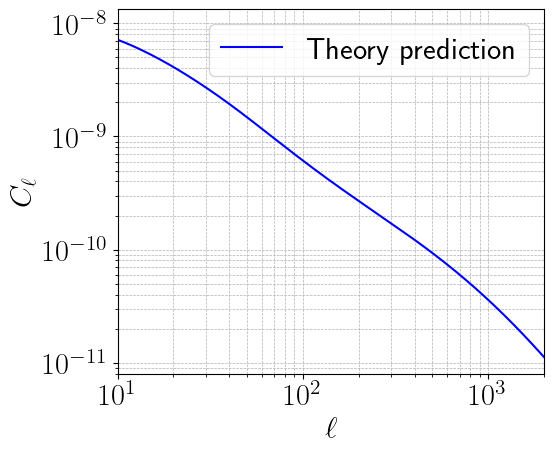

In [15]:
# times coef (2pi )

# set plots font to 18 and activate tex rendering
plt.rcParams.update({"font.size": 22, "text.usetex": True})
plt.figure(figsize=(6, 5))
plt.loglog(cl_shear.wavenumber, cl_shear.spectra[-4], label="Theory prediction", color="blue")
plt.xlabel(r"$\ell$")
plt.xlim(10, 2000)
plt.ylabel(r"$C_\ell$")
plt.legend()
plt.tight_layout()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.savefig("illustrations/theory_pk.svg", dpi=1200, transparent=False)
plt.show()

## 1 — Initial Conditions

Scale factor target: [0.86512261]  (z ≈ [0.15590552])


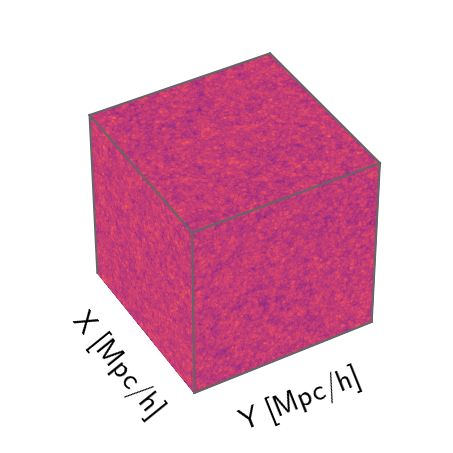

Saved: illustrations/01_initial_conditions.png


In [18]:
initial_field = jfli.gaussian_initial_conditions(
    key,
    mesh_size,
    box_size,
    cosmo=cosmo,
    nside=nside,
)

a_target = jc.background.a_of_chi(cosmo, initial_field.max_comoving_radius - shell_width / 2.0)
print(f"Scale factor target: {a_target}  (z ≈ {1 / a_target - 1})")

fig, _ = initial_field.plot(
    colorbar=False,
    labels=["X [Mpc/h]", "Y [Mpc/h]", ""],
    titles=[""],
    cmap="magma",
    figsize=(5, 5),
)
fig.savefig("illustrations/01_initial_conditions.png", dpi=600, bbox_inches="tight", transparent=True)
plt.show()
print("Saved: illustrations/01_initial_conditions.png")

## 2 — LPT Displacement

Shell comoving centers [Mpc/h]: [437.5 312.5 187.5  62.5]
Shell scale factors: [0.86850058 0.90338077 0.9403024  0.97949002]
Shell redshifts: [0.15140971 0.10695294 0.06348766 0.02093945]


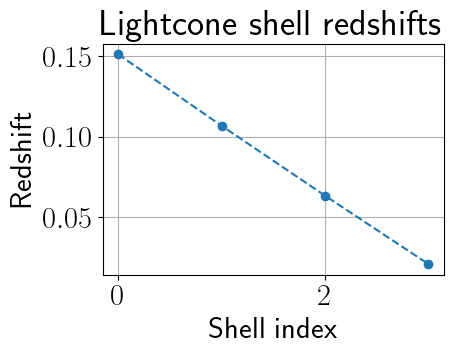

In [19]:
r_center, a_center = jfli.compute_lightcone_shells(cosmo, initial_field, 4)
z_center = jc.utils.a2z(a_center)

print(f"Shell comoving centers [Mpc/h]: {r_center}")
print(f"Shell scale factors: {a_center}")
print(f"Shell redshifts: {z_center}")

fig = plt.figure(figsize=(5, 4))
plt.plot(jnp.arange(4), z_center, linestyle="--", marker="o")
plt.xlabel("Shell index")
plt.ylabel("Redshift")
plt.title("Lightcone shell redshifts")
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
dx, p = jfli.lpt(cosmo, initial_field, ts=a_center, order=1)

print(f"Scale factor: {a_center}  (z ≈ {1 / a_center - 1})")
print(f"Particle array shape: {dx.array.shape}")

Scale factor: [0.86850058 0.90338077 0.9403024  0.97949002]  (z ≈ [0.15140971 0.10695294 0.06348766 0.02093945])
Particle array shape: (256, 256, 256, 3)


## 3 — Final 3D Density (log-scaled)

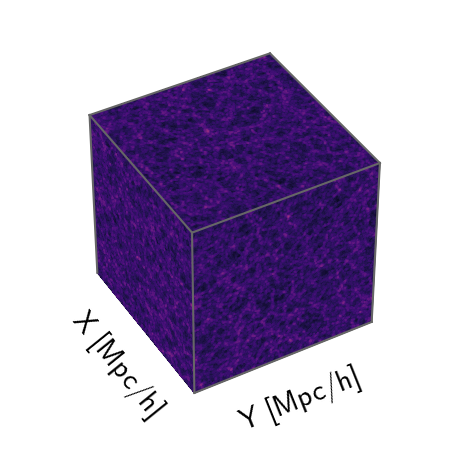

Saved: illustrations/02_final_density.png


In [21]:
density_3d = dx.paint()

fig, _ = density_3d.apply_fn(jnp.log1p).plot(
    colorbar=False,
    labels=["X [Mpc/h]", "Y [Mpc/h]", ""],
    titles=[""],
    cmap="magma",
    figsize=(5, 5),
    project_slices=32,
)
fig.savefig("illustrations/02_final_density.png", dpi=600, bbox_inches="tight", transparent=True)
plt.show()
print("Saved: illustrations/02_final_density.png")

## 4 — Spherical (HEALPix / Mollweide) Projection

In [ ]:
spherical_map, _ = jfli.lpt(
    cosmo, initial_field, ts=a_center, order=1, painting=jfli.PaintingOptions(target="spherical")
)
spherical_map = spherical_map.ud_sample(new_nside=128)

HEALPix map shape: (4, 196608), nside=128


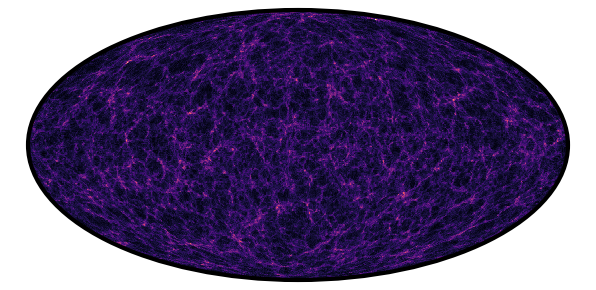

Saved: illustrations/03_spherical_projection.png


In [45]:
print(f"HEALPix map shape: {spherical_map.array.shape}, nside={spherical_map.nside}")

spherical_map_log = spherical_map.apply_fn(jnp.log1p)

# 1. Plot using projview with all the extra visual elements turned off
fig = plt.figure(figsize=(6, 3))
spherical_map_log[2].plot(
    ax=fig.gca(),
    titles="",
    cmap="magma",
    colorbar=False,
    border_linewidth=3,
)

plt.savefig("illustrations/03_spherical_projection.png", dpi=600, bbox_inches="tight", transparent=True)
plt.show()

print("Saved: illustrations/03_spherical_projection.png")

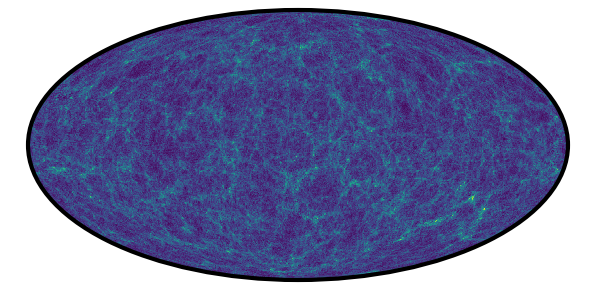

Saved: illustrations/04_lensing_map.png


In [46]:
kappa_maps = jfli.born(cosmo, spherical_map, nz_shear=jnp.array([0.1, 0.15]))
kappa_maps_log = kappa_maps.apply_fn(jnp.log1p)

figure = plt.figure(figsize=(6, 3))
kappa_maps_log[2].plot(
    ax=figure.gca(),
    titles="",
    cmap="viridis",
    colorbar=False,
    border_linewidth=3,
)


plt.savefig("illustrations/04_lensing_map.png", dpi=600, bbox_inches="tight", transparent=True)
plt.show()

print("Saved: illustrations/04_lensing_map.png")